# Predictability of the Poverty Probability Index

This project predicts the probability that a person will fall below the poverty line, based on general features.  <a href="http://www.povertyindex.org/about-ppi">Innovations for Poverty Action</a> (IPA) defines poverty line as $2.50 (US) per day.  IPA has defined the Poverty Probability Index, or **PPI**, to calculate the probability that an individual falls below the poverty line.  The index is calculated based on a survey of 10 questions that IPA distributes.

Can the PPI be predicted from more general data?  <a href="http://finclusion.org/">Financial Inclusion Insights</a> has broad, largely categorical data on wide a range of individuals across the globe.  This data includes basic information like country of residence, religion, and education level.  The project here is to see whether this data can predict the PPI, and if so, how well.

### Importing the Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

warnings.filterwarnings("ignore", category = FutureWarning)

print('Packages loaded.')

Packages loaded.


In [3]:
df = pd.read_csv('data/train_values.csv', index_col = 'row_id')
features = df.columns
labels = pd.read_csv('data/train_labels.csv', index_col = 'row_id')
df = df.join(labels)

### Exploring the data

This notebook will do some very brief data exploration.  For more information, see the data report included in this repository.

The dataset includes features in six general categories: demographics, education, employment, economic, phone, and financial inclusion.  The set of features in the data can be reviewed <a href="https://datasciencecapstone.org/competitions/15/predicting-poverty/page/47/">here.</a>  More information about the features is given in the corresponding data report for this project.

The data has 12,000 records.

In [4]:
df.shape

(12600, 59)

Distribution of the PPI:

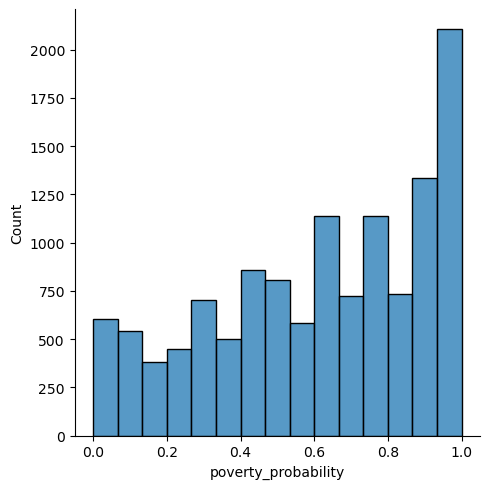

In [5]:
label = 'poverty_probability'
sns.displot(df[label], kde = False, bins = 15)
plt.show()

## Predictive Range

How informative are the features?  Here, I take a basic approach (perhaps overly simplistic) - the range of target values that a feature can predict in principle.  This is given by the difference between the max and min PPI values for each feature.  Call this the individual "predictive range" of each feature.  I apply this metric to categorical features and those with a small range of integer values.

Analyzing these features, the predictive range is poor, with a mean of 0.11.  

In [16]:
columns = df[features].columns[df[features].dtypes != 'float64']
info = pd.Series(name = 'Info')

for col in columns:
    s = df.groupby(col)['poverty_probability'].mean()
    info[col] = s.max() - s.min()    

info.sort_values(ascending = False, inplace = True)
info = info.round(2)

predictionRanges = info
predictionRanges.name = 'Range'

predictionRanges.describe()

count    50.000000
mean      0.116200
std       0.087572
min       0.020000
25%       0.040000
50%       0.095000
75%       0.160000
max       0.370000
Name: Range, dtype: float64

Some features show significant "predictive range," but it is not yet clear how much predictive power this will yield in the R-squared metric, and more importantly, how much they will contribute as a whole.

In [14]:
predictionRanges.head()

num_financial_activities_last_year     0.37
num_informal_institutions_last_year    0.37
phone_technology                       0.28
country                                0.26
num_formal_institutions_last_year      0.25
Name: Range, dtype: float64

The same information is represented visually below.

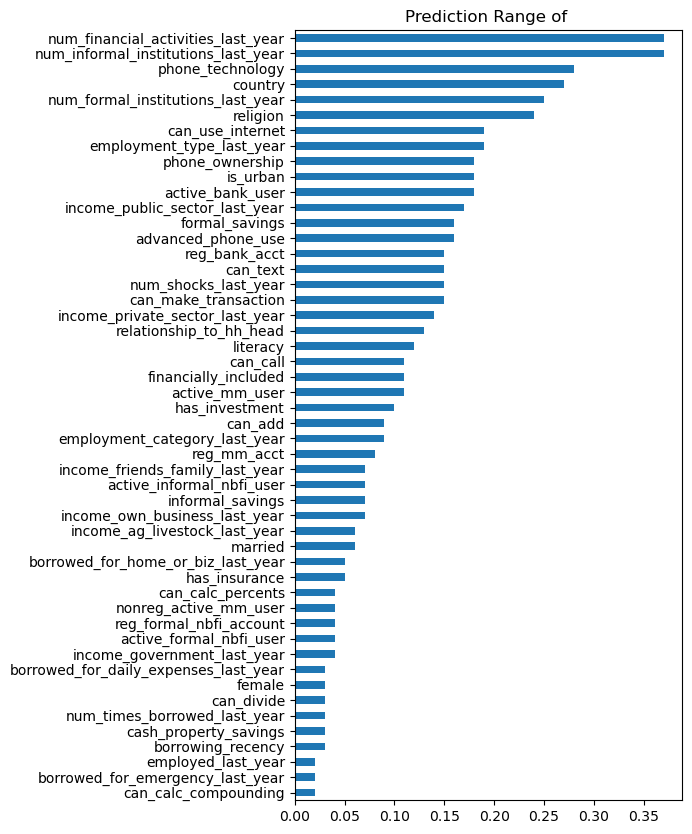

In [60]:
plt.figure(figsize = (5, 10))
info.sort_values().head(8).plot.barh()
info.sort_values().plot.barh()
plt.title('Prediction Range of ')
plt.show()

The most informative features include the number of financial activities last year, the country of residence, and the level of phone technology.  Surprisingly, whether the individual was *employed* last year makes almost no difference.  Being married, being female, and having insurance are not very informative.

In [9]:
predictionRanges.to_excel('Prediction Ranges.xlsx')
print('exported')

exported


## Cleaning and Analysis

It is time to look at the features in more detail.  The type of problem here is regression.  The PPI is a continuous numeric variable.  Ideally, we would want multiple float-type features to predict it.  Int-types are not as good, but potentially quite helpful.

The cell below breaks down the features by type.  It shows 16 numeric features total (combining both floats and ints).  This looks promising, but as the analysis will go on, we will see that things are not so good.

In [61]:
df[features].dtypes.value_counts()

bool       37
float64     8
int64       8
object      5
Name: count, dtype: int64

This cell cleans removes sparse features.  "Sparse features" are defined here as features that are mostly blank or null.  Here the standard for mostly null is 80% or more.

In [62]:
# Drop sparse columns.
s = {}
for column in df.columns:
    s[column] = df[column].isnull().sum()

standard = 1 - 0.80    
s = pd.Series(s)
null_tolerance = round(len(df) * standard)
empties = list(s[s > null_tolerance].index)
df = df.drop(columns = empties)

# Drop emtpy rows
df.dropna(inplace = True) 

Again, many features are not very informative.  The cell below shows how the feature of being employed last year relates to PPI.  Surprisingly, whether someone was employed last year made almost no difference to their PPI: only 2 percentage points.

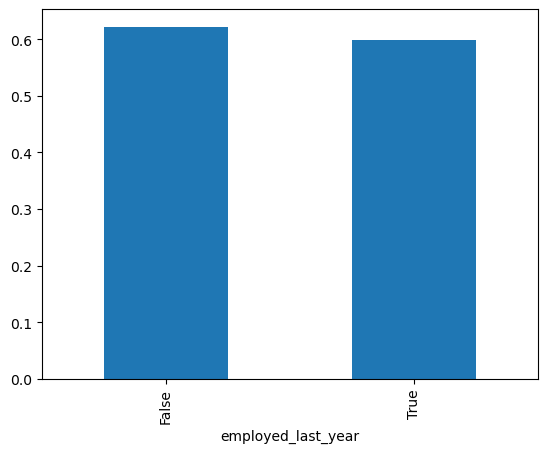

In [63]:
feature = 'employed_last_year'
s = df.groupby(feature).poverty_probability.mean()
s.plot.bar()
plt.show()

This cell removes uninformative features.  Besides floats, all these features will have a small number of possible values.  The criterion for informativeness here is min-max difference.  If the argument with the highest average PPI is barely higher than the lowest (with a cutoff of 5 percentage points), the feature is rejected.

In [64]:
info < 0.05
info[info < 0.05].index

Index(['active_formal_nbfi_user', 'income_government_last_year',
       'can_calc_percents', 'reg_formal_nbfi_account', 'nonreg_active_mm_user',
       'borrowed_for_daily_expenses_last_year', 'female', 'can_divide',
       'num_times_borrowed_last_year', 'cash_property_savings',
       'borrowing_recency', 'employed_last_year',
       'borrowed_for_emergency_last_year', 'can_calc_compounding'],
      dtype='object')

### Dropping Uninformative Columns

In [65]:
drop_cols = info[info < 0.05].index
df = df.drop(columns = drop_cols)
features = df.columns[:-1]

print('Number features dropped:', len(drop_cols))

Number features dropped: 14


## Miscast Floats

Several features have the wrong data types.  One is "education_level."  This feature is coded as a float (shown below), but its description (and quartile values) suggest otherwise.

In [66]:
col = 'education_level'
df[col].describe()

count    12068.000000
mean         1.316291
std          0.903742
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          3.000000
Name: education_level, dtype: float64

Attempting a scatter plot of PPI vs education_level highlights the problem.

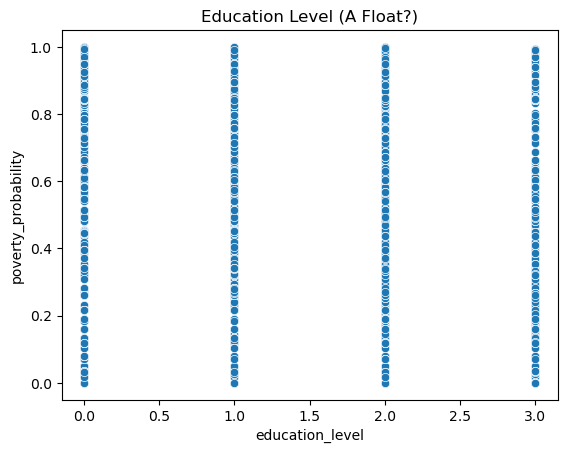

In [67]:
sns.scatterplot(x = 'education_level', y = 'poverty_probability', data = df)
plt.title('Education Level (A Float?)')
plt.show()

Clearly, this value is not really a float.  It is probably best to cast it as categorical.

In fact, *none* of the remaining floats in this feature set represent continuous variables.  We can see that by checking how many unique values each has. 

In [68]:
floats = df.columns[df.dtypes == 'float64'][:-1]
floats

counts = pd.Series()
for col in floats:
    counts[col] = len(df[col].value_counts())
    
counts

age                             83
education_level                  4
share_hh_income_provided         5
avg_shock_strength_last_year    41
dtype: int64

Reviewing the feature information prompts recoding of some of these features.

In [69]:
'education_level', 'share_hh_income_provided'
col = 'education_level'
df[col] = df[col].astype(int).astype(str)
df[col].head()

col = 'share_hh_income_provided'
df[col] = df[col].astype(int)

## Miscast Integers

Some features coded as integers should be categorical instead.  One integer-type feature is a special case.  This is "num_formal_institutions_last_year".  This feature does not *correlate* with PPI.  Yet the feature is very *informative* about PPI.  

The value of PPI is not monotonic on these features.  To capture the information these features contain, they will be converted to categorical variables. 

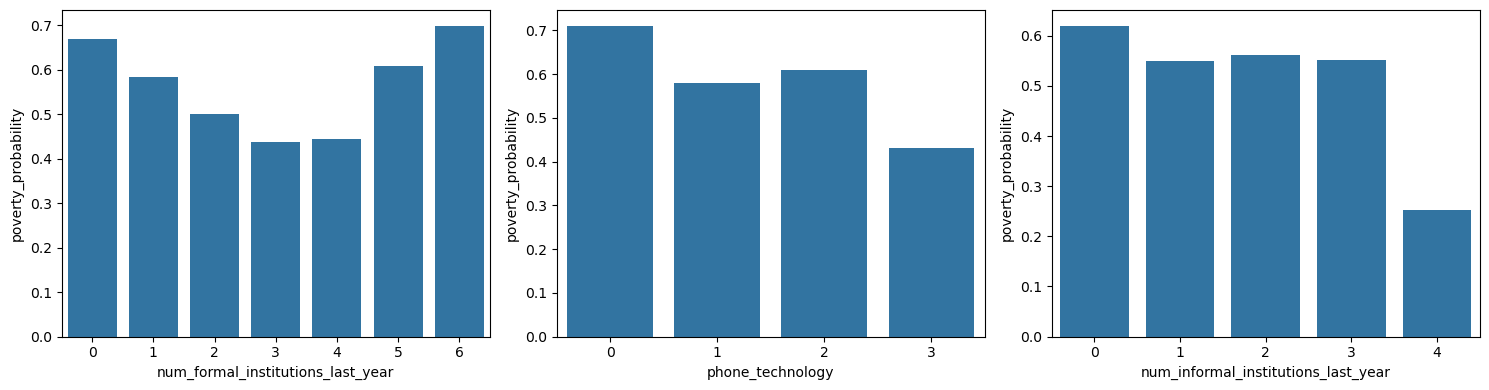

In [70]:
special = ['num_formal_institutions_last_year',
           'phone_technology',
           'num_informal_institutions_last_year']  

fig, axes = plt.subplots(nrows=1, ncols=3, figsize = (15, 4))
for i in range(3):
    col = special[i]
    sns.barplot(x = col, y = 'poverty_probability', data = df, ci = None, ax = axes[i])

plt.tight_layout()  

The cell below recodes these special-case integers as categorical values by converting their values to strings.  

In [71]:
for col in special:
    df[col] = df[col].astype(str)

At this point, a major problem is emerging.  The various issues with the numeric features--being mostly null, being improperly coded, or being uninformative--has left almost no numeric information.  In particular, there are only two floats left ... 

In [72]:
features = df.columns[:-1]
n = len(features)
print('Number of features:', n)
n = (df[features].dtypes == 'float64').sum()
print('Number of floats:', n)
n = (df[features].dtypes == 'int64').sum()
print('Number of integers:', n)

Number of features: 40
Number of floats: 2
Number of integers: 4


... and neither float provides much information about the label.  The scatter plots below show no relationship; they might as well be bad fabric patterns.  

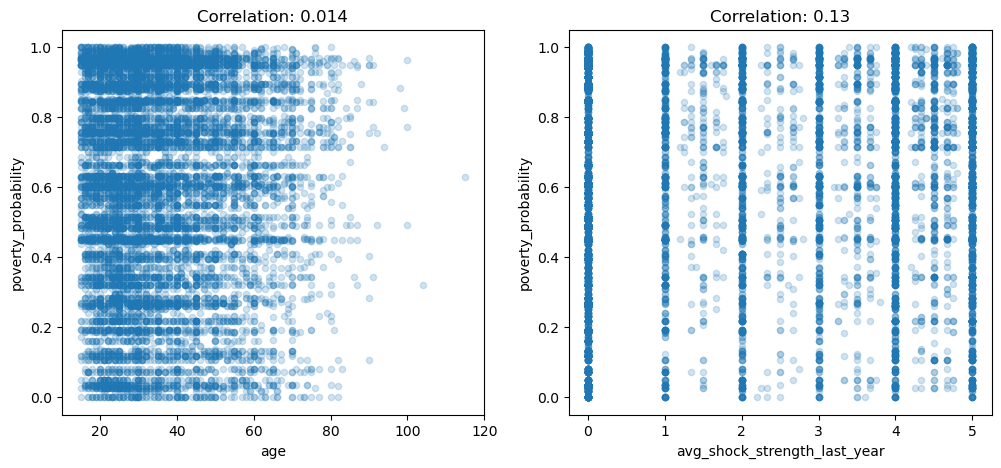

In [73]:
fig, axes = plt.subplots(1,2, figsize = (12,5))
plt.subplots_adjust(hspace=0.5)

columns = ['age', 'avg_shock_strength_last_year']

for i in range(2):
    col = columns[i]
    ax = axes[i]
    df.plot.scatter(x = col, y='poverty_probability', alpha = 0.2, ax = ax)
    corr = df[col].corr(df.poverty_probability).round(3)
    title = 'Correlation: '+str(corr)
    ax.set_title(title)
    
plt.show()

With a scant numerical basis for regression, prospects for a strong prediction are not good.

## Encoding

The following cells prepare the data for modeling.

In [74]:
import numpy.random as nr
from sklearn import preprocessing, linear_model
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score

In [75]:
features = df.columns[:-1]
X = df[features]
y = df.poverty_probability

# "Features" (capitalized) is the Numpy array for applying ML models.
Features = np.empty((df.shape[0],0))

### Encoding Categoricals

In [76]:
def encode_string(cat_features):
    '''
    Encodes categorical features with one-hot encoding.
    '''
    ## First encode the strings to numeric categories
    enc = preprocessing.LabelEncoder()
    enc.fit(cat_features)
    enc_cat_features = enc.transform(cat_features)
    ## Now, apply one hot encoding.
    ## The try block improves compatibility. 
    try:
        ohe = preprocessing.OneHotEncoder(categories = 'auto')
    except TypeError:
        ohe = preprocessing.OneHotEncoder()
    encoded = ohe.fit(enc_cat_features.reshape(-1,1))
    return encoded.transform(enc_cat_features.reshape(-1,1)).toarray()

In [77]:
categorical_columns = df.columns[
    (df.dtypes == 'bool') | (df.dtypes == 'object')]

for column in categorical_columns:
    x = encode_string(df[column])
    Features = np.concatenate([Features, x], axis = 1)

### Encoding Numerics

In [78]:
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

numeric_columns = df.columns[(df.dtypes == 'float64') | (df.dtypes == 'int64')]
numeric_columns = list(numeric_columns)
numeric_columns.remove('poverty_probability')
numeric_columns

for column in numeric_columns:
    x = df[column]
    x = np.array(x).reshape(-1,1)
    scaler = preprocessing.StandardScaler().fit(x)
    x = scaler.transform(x)
    Features = np.concatenate([Features, x], axis = 1)

In [79]:
from sklearn.model_selection import train_test_split
label = df.poverty_probability
X, X2, y, y2 = train_test_split(Features, label, random_state = 0)

print('X2 shape:', X2.shape)

X2 shape: (3017, 105)


The split leaves about 3000 data in the test set.

# Modeling

The following code will provide standard visualization for the results of applying different models.  Model performance will be judged by the R^2 metric.  (From this point, this notebook will simply denote the metric "R2".)

In [80]:
def scatter(y, yp, title = ''):
    '''
    Justin's scatter for presenting model performance.
    y - true y values.  (Intended for y2.)
    yp - predicted y values.
    ''' 
    plt.figure()
    plt.scatter(y, yp, alpha = .2)
    r2 = r2_score(y, yp)
    r2 = round(r2, 3)
    plt.xlabel('poverty_probability')
    plt.ylabel('prediction')
    t = title + '\nR2: '+str(r2)
    plt.title(t)  

In [81]:
results = pd.Series(name = 'R2 Scores')

## Linear Regression

Linear regression does not achieve a high R2 score, generally speaking.  But it will prove difficult to improve much on this model's performance.  In hindsight, we might say that basic linear regression performs well.

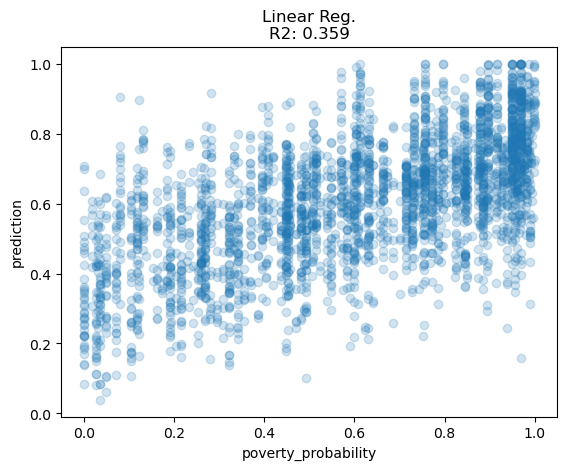

In [82]:
lin_mod = linear_model.LinearRegression()
lin_mod.fit(X, y)
yp = lin_mod.predict(X2)

yp = pd.Series(yp, index = y2.index)
# Linear regression has given a few far-off predictions.
yp = yp.map(lambda x: max(x, 0))
yp = yp.map(lambda x: min(x, 1))

scatter(y2, yp, title = "Linear Reg.")

r2 = r2_score(y2, yp)
r2 = round(r2, 3) 
results['Linear Reg.'] = r2

Regularization does not help much here.  The cell below performs a hasty parameter sweep for ridge regression.

In [83]:
top_alpha = 0
top_r2 = 0

alist = [0.01 * 2**i for i in range(20)]

for alpha in alist:
    clf = Ridge(alpha=alpha)
    clf.fit(X, y)
    yp = clf.predict(X2)
    r2 = r2_score(y2, yp)
    r2 = round(r2, 3) 
    if r2 > top_r2:
        (top_alpha, top_r2) = (alpha, r2)    
        
print('Best alpha:', top_alpha)
print('Best R2:', top_r2)
results['Lin. w Ridge'] = top_r2        

Best alpha: 0.01
Best R2: 0.359


In [84]:
alpha = 5
ridge_lin  = Ridge(alpha)
ridge_lin.fit(X, y)  

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",5
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None



## Decision Tree Regressor

On default settings, a decision tree regressor achieves a **negative** R2 score on the data.  

-0.128

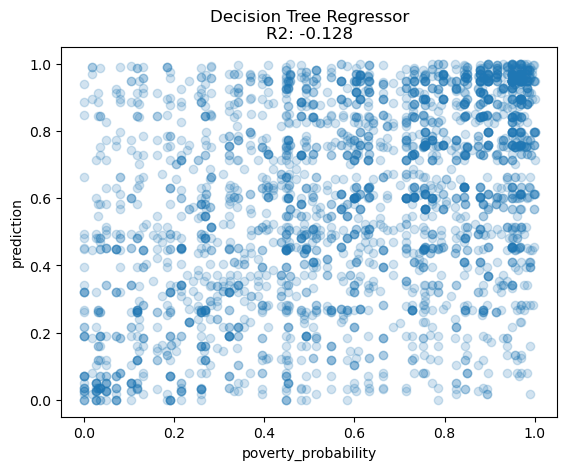

In [85]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor(random_state=0, max_depth = None)
dtr.fit(X, y)
yp = dtr.predict(X2)
r2 = r2_score(y2, yp)
r2 = round(r2, 3) 

scatter(y2, yp, 'Decision Tree Regressor')
r2

The cell below tries limiting the Decision Tree Regressor by sweeping across maximum depths. The result of the sweep changes some based on previous conditions, but 7 is reliably near-optimal.  

Even at its best, the decision tree regressor cannot beat simple linear regression.

Best R2: 0.314


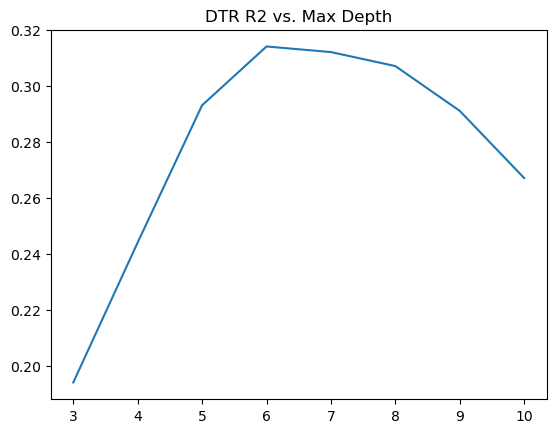

In [86]:
depth_list = range(3,11)
s = pd.Series(name = 'DTR performance')

for depth in depth_list:
    dtr = DecisionTreeRegressor(random_state=0, max_depth = depth)
    dtr.fit(X, y)
    yp = dtr.predict(X2)
    r2 = r2_score(y2, yp)
    r2 = round(r2, 3) 
    s.loc[depth] = r2

results['DTR'] = s.max()
flag = s.max()
dtrDepthSweep = s

print('Best R2:', s.max())
s.plot()   
plt.title('DTR R2 vs. Max Depth')
plt.show()

## AdaBoost

The following cell tries AdaBoost with default settings.  AdaBoost performs the worst of the three.

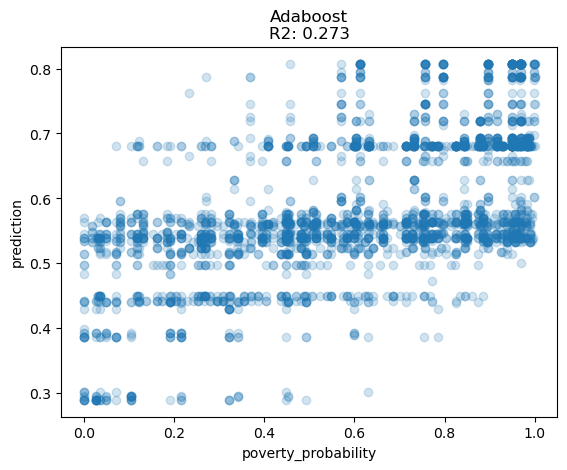

In [87]:
from sklearn.ensemble import AdaBoostRegressor

clf = AdaBoostRegressor(random_state=0)
clf.fit(X, y)  
yp = clf.predict(X2)

yp = pd.Series(yp, index = y2.index)
scatter(y2, yp, title = "Adaboost")

r2 = r2_score(y2, yp)
r2 = round(r2, 3) 
results['Adaboost'] = r2

## Results

The best performing model in this set was *basic linear regression!*  

In [88]:
results.round(2)

Linear Reg.     0.36
Lin. w Ridge    0.36
DTR             0.31
Adaboost        0.27
Name: R2 Scores, dtype: float64

It is worth noting this score is close to the max "prediction range" in the feature set as defined earlier.  Although without more analysis, it is unclear how much this may be a coincidence.

In [89]:
predictionRanges.head(1)

num_financial_activities_last_year    0.37
Name: Info, dtype: float64

Overall, the PPI is cannot be predicted well by the given data.  This is not much surprise given the limitations of the data investigated earlier.

In the interest of time, the project ends here.  Admittedly, further analysis would have benefitted the project.  Further directions for the project include:
- A more sophisticated measure of predictive power of the features, especially mutual information on the target or sequential univariate regression.
- Investigating shared information among the features such as with chi-squared.
- Attempting imputing on gappy features.